# Week 4 — Asynchronous Training & Parameter Servers

**Distributed Systems for Machine Learning**

---

Synchronous data parallelism (Week 3) has a flaw: it runs at the speed of the **slowest worker** (the *straggler*). If one GPU is slow, everyone waits at the all-reduce barrier. **Asynchronous** methods drop the barrier — workers push updates whenever they're ready — trading *statistical efficiency* for *hardware efficiency*.

This week:

- The **parameter-server (PS)** architecture: stateless workers, stateful servers.
- **Synchronous vs asynchronous** SGD and the straggler problem.
- **Gradient staleness**: an async worker's gradient is computed against an *old* parameter version. We model and visualize how staleness slows convergence.
- **Hogwild!**: lock-free async SGD, and *why* it works for sparse problems.
- **Bounded staleness (SSP)**: the middle ground that bounds how stale any update may be.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
np.random.seed(4)
plt.rcParams["figure.figsize"]=(9,4.5); plt.rcParams["axes.grid"]=True

## 1. The parameter-server architecture

Split roles:
- **Servers** hold the canonical parameters $\theta$, sharded by key. They apply updates: `push(grad)` and answer `pull()`.
- **Workers** are stateless: pull the latest $\theta$, compute a gradient on a mini-batch, push it back.

Communication is **worker↔server** (a star), not the all-to-all of all-reduce. This scales the *number of workers* easily but makes the server a potential bottleneck (sharding fixes that). Let's implement a single logical server.

In [2]:
class ParameterServer:
    def __init__(self, dim, lr=0.05):
        self.theta = np.zeros(dim)
        self.lr = lr
        self.version = 0
    def pull(self):
        return self.theta.copy(), self.version
    def push(self, grad):
        self.theta -= self.lr * grad
        self.version += 1
        return self.version

# shared toy problem
B,d=800,10
X=np.random.randn(B,d); w_true=np.random.randn(d)
y=X@w_true+0.1*np.random.randn(B)
def local_grad(w, idx):
    bs=len(idx); r=X[idx]@w-y[idx]; return (2.0/bs)*(X[idx].T@r)
def mse(w): r=X@w-y; return float(np.mean(r*r))

## 2. Synchronous PS vs the straggler

In **synchronous** mode the server waits for all $P$ workers' gradients, averages, and steps once. Its wall-clock per round is `max` over worker speeds — a single straggler dominates. We simulate worker speeds as random compute times and measure the barrier cost.

worker speeds: [3. 1. 1. 1. 3. 1. 1. 1.]
sync round wall-time = slowest = 3.0
mean worker time     = 1.50  (wasted: 1.50)


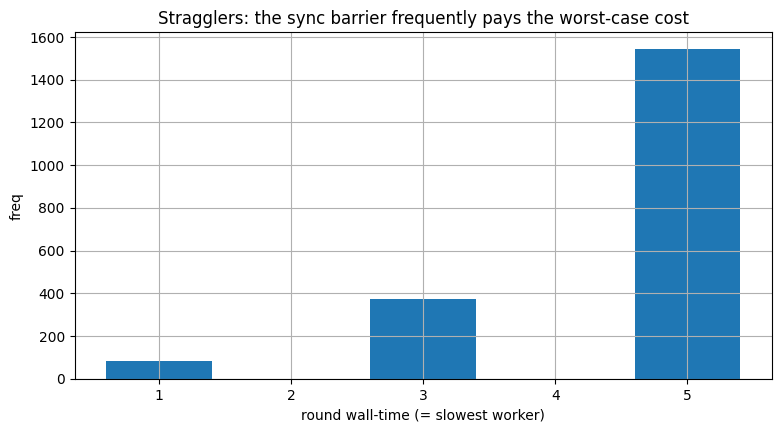

In [3]:
def simulate_sync_round(worker_speeds):
    """Wall time of one synchronous round = slowest worker."""
    return max(worker_speeds)

P=8
np.random.seed(7)
# most workers fast (~1.0), occasional straggler (~3-5x)
speeds = np.random.choice([1.0,1.0,1.0,1.0,3.0,5.0], size=P)
print("worker speeds:", speeds)
print(f"sync round wall-time = slowest = {simulate_sync_round(speeds):.1f}")
print(f"mean worker time     = {speeds.mean():.2f}  (wasted: {simulate_sync_round(speeds)-speeds.mean():.2f})")
# distribution of barrier overhead
overheads=[max(np.random.choice([1,1,1,1,3,5],P)) for _ in range(2000)]
plt.hist(overheads,bins=range(1,7),align="left",rwidth=.8)
plt.xlabel("round wall-time (= slowest worker)"); plt.ylabel("freq")
plt.title("Stragglers: the sync barrier frequently pays the worst-case cost"); plt.show()

## 3. Asynchronous SGD and gradient staleness

In **async** mode each worker pulls, computes, pushes — *no barrier*. By the time a worker pushes, the server may have advanced several versions. The **staleness** $\tau$ = (server version at push) − (version the gradient was computed on). The update applied is

$$\theta_{t+1} = \theta_t - \eta\,\nabla L(\theta_{t-\tau}),$$

a gradient evaluated at an **old** point. Small staleness is tolerable; large staleness can slow or destabilize training. We simulate async SGD with random staleness and compare convergence to synchronous.

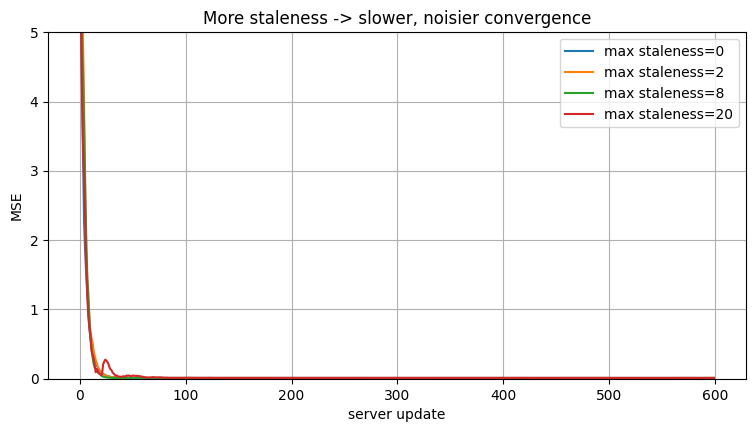

In [4]:
def run_async(P=8, steps=600, lr=0.05, max_stale=0, batch=32):
    """max_stale=0 reproduces sync-like behavior; larger = more async."""
    ps = ParameterServer(d, lr=lr)
    history = deque()   # pending (theta_snapshot, grad) to model delayed apply
    losses=[]
    for t in range(steps):
        # a worker pulls a (possibly stale) snapshot
        stale = np.random.randint(0, max_stale+1)
        snap = history[-1-stale][0] if len(history)>stale and stale>0 else ps.theta.copy()
        idx = np.random.randint(0,B,batch)
        g = local_grad(snap, idx)
        ps.push(g)
        history.append((ps.theta.copy(), g))
        if len(history)>max_stale+2: history.popleft()
        losses.append(mse(ps.theta))
    return losses

for ms in (0,2,8,20):
    L=run_async(max_stale=ms)
    plt.plot(L,label=f"max staleness={ms}")
plt.ylim(0,5); plt.xlabel("server update"); plt.ylabel("MSE"); plt.legend()
plt.title("More staleness -> slower, noisier convergence"); plt.show()

**Trade-off in one picture:** synchronous SGD has *zero* staleness (best statistics) but pays the straggler barrier (worst hardware utilization). Async SGD has *perfect* hardware utilization but pays in staleness. The right choice depends on how heterogeneous your cluster is and how staleness-tolerant your model is.

## 4. Hogwild! — lock-free async

**Hogwild!** (Niu et al., 2011) goes fully lock-free: multiple threads update *shared* parameters with **no locks at all**, accepting occasional overwrites. The surprising theorem: if updates are **sparse** (each touches few coordinates), the collisions are rare and SGD still converges at nearly the serial rate.

We simulate it: two "threads" interleave read-modify-write on shared params, with a probability that a write is clobbered. For a sparse problem, throughput rises with thread count while convergence is barely hurt.

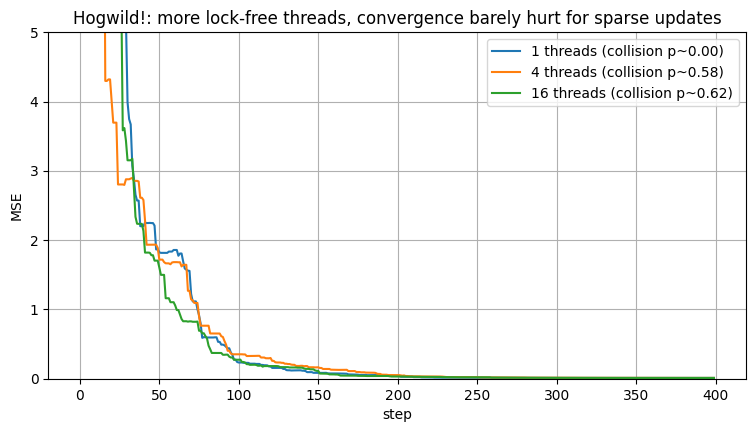

In [5]:
def hogwild_sim(n_threads, sparsity=0.1, steps=400, lr=0.1):
    """Each update touches a 'sparsity' fraction of coords; collisions drop updates."""
    w=np.zeros(d); losses=[]
    p_collision = 1-(1-1.0/n_threads)**(n_threads-1)  # rough collision prob
    for t in range(steps):
        idx=np.random.randint(0,B,16)
        g=local_grad(w,idx)
        mask=np.random.rand(d)<sparsity
        # with some prob a coordinate update is lost (clobbered)
        keep=np.random.rand(d) > (p_collision*0.3)
        w-=lr*g*mask*keep
        losses.append(mse(w))
    return losses, p_collision

for nt in (1,4,16):
    L,pc=hogwild_sim(nt)
    plt.plot(L,label=f"{nt} threads (collision p~{pc:.2f})")
plt.ylim(0,5); plt.xlabel("step"); plt.ylabel("MSE"); plt.legend()
plt.title("Hogwild!: more lock-free threads, convergence barely hurt for sparse updates"); plt.show()

## 5. Bounded staleness (Stale Synchronous Parallel)

**SSP** is the principled middle ground: workers run async, *but* the fastest worker is **blocked** if it gets more than $s$ steps ahead of the slowest. This caps staleness at $s$ — guaranteeing convergence properties of sync — while still tolerating mild stragglers. We model how the staleness *bound* $s$ trades convergence quality against the fraction of time fast workers stall.

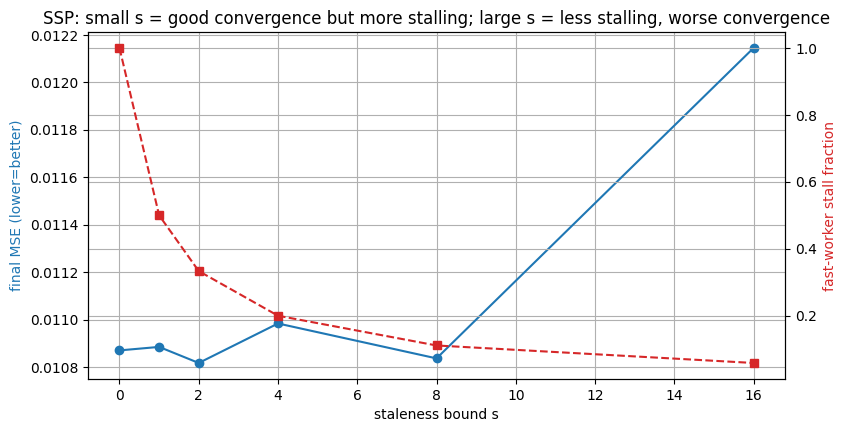

In [6]:
def ssp_tradeoff(s_values, P=8):
    rows=[]
    for s in s_values:
        # convergence proxy: final MSE after fixed updates (more bound -> closer to sync)
        L=run_async(max_stale=s, steps=400)
        conv=L[-1]
        # stall proxy: fast workers wait more often when bound is tight
        stall_fraction = 1.0/(s+1)
        rows.append((s, conv, stall_fraction))
    return rows

rows=ssp_tradeoff([0,1,2,4,8,16])
s=[r[0] for r in rows]; conv=[r[1] for r in rows]; stall=[r[2] for r in rows]
fig,ax1=plt.subplots()
ax1.plot(s,conv,"o-",color="tab:blue"); ax1.set_ylabel("final MSE (lower=better)",color="tab:blue")
ax1.set_xlabel("staleness bound s")
ax2=ax1.twinx(); ax2.plot(s,stall,"s--",color="tab:red"); ax2.set_ylabel("fast-worker stall fraction",color="tab:red")
plt.title("SSP: small s = good convergence but more stalling; large s = less stalling, worse convergence")
plt.show()

## Exercises

1. **Server sharding.** Extend `ParameterServer` to shard `theta` across $K$ servers by coordinate, so pushes/pulls hit different servers. Why does this remove the single-server bandwidth bottleneck?
2. **Staleness-aware LR.** Implement a rule that scales the learning rate down by $1/(\tau+1)$ for a gradient of staleness $\tau$. Show it stabilizes the high-staleness runs from §3.
3. **Straggler mitigation.** Implement **backup workers**: launch $P+b$ workers, take the first $P$ gradients each round, drop the slowest $b$. Simulate how this reduces the sync barrier time and what bias it introduces.
4. **Hogwild! sparsity sweep.** Vary `sparsity` from 0.01 to 1.0 and plot how convergence degrades with thread count. Confirm Hogwild!'s promise holds for sparse and breaks for dense updates.
5. **Choose the regime.** Given a cluster where 1-in-10 workers is 4× slow, and a dense model, argue quantitatively whether sync all-reduce, async PS, or SSP gives the best *time-to-accuracy*.
